This updated documentation integrates the "Teacher-Student" architectural strategy into the overview of your models.

---

# Error Profile Classification Documentation

## Overview

This notebook implements a **Teacher-Student** framework to model and predict linguistic error profiles. The system leverages two distinct BiLSTM models to translate word pairs into error distributions, with one model acting as a teacher to refine the knowledge learned by the student.

## Framework: Teacher-Student Strategy

The architecture is designed to capture the nuances of misspelling vulnerabilities by decoupling model training from predictive assessment:

* **Model 1 (Teacher):** Acts as the primary learner. It is trained on the dataset to identify patterns of misspellings and generate target error profiles. By learning the structure of these errors, it serves as the reference point for what "correct" error distribution looks like.
* **Model 2 (Student):** Learns from the outputs of Model 1. Its objective is to predict error profiles for given words. By training against the teacher's profiles, Model 2 aims to generalize the misspelling vulnerabilities, allowing it to predict potential errors even when not explicitly present in the training set.

## Workflow Summary

### 1. Data Import & Preprocessing

* **Data Source**: Uses `final_pairs_with_error_labels_WIP_for_INSPECTIONs.xlsx`.
* **Label Encoding**: Categorical errors are encoded for model compatibility.
* **Pair Encoding**: Correct and incorrect words are tokenized via a character-level map (`correct_word + <SEP> + incorrect_word`).

### 2. Model Architectures

* **Common Base**: Both models utilize a **BiLSTM** (Bidirectional LSTM) architecture with 2 layers, `hidden_dim=64`, and `dropout=0.3` to process character sequences in both directions.
* **Model 1 Focus**: Concentrates on maximizing classification accuracy to ensure the teacher's profile generation is reliable.
* **Model 2 Focus**: Concentrates on **Cosine Similarity**. It is optimized to align its output distribution with the target profiles identified by the teacher.

---

## Performance Monitoring

To validate the Teacher-Student interaction, the notebook tracks performance across two key metrics:

| Metric | Target | Role |
| --- | --- | --- |
| **Accuracy** | 0.9 | Used by **Model 1** to confirm high-fidelity label prediction. |
| **Cosine Similarity** | 0.487422 | Used by **Model 2** to assess alignment with teacher profiles. |

---

## Visualization Summary

The training progress is visualized with benchmark markers indicating the target performance goals:

* **Model 1 (Accuracy)**: Plots the train/validation accuracy. The benchmark is marked with a red star at the final epoch to verify if the teacher has reached the 0.9 accuracy threshold.
* **Model 2 (Similarity)**: Plots the cosine similarity. The benchmark is marked with a red star to evaluate if the student model has successfully matched the teacher's distribution characteristics.
---
## Data Import

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path

In [4]:
data_path = "../../data/final_pairs_with_error_labels_WIP_for_INSPECTIONs.xlsx"

In [5]:
labelled_df = pd.read_excel(data_path)
print(f"dataset shape: {labelled_df.shape}")
labelled_df.head(5)

dataset shape: (3468, 3)


,correct,incorrect,error_type
0,apennines,apenines,missing_letter
1,apennines,appenines,complex/multiple
2,athenian,athenean,phoneme_substitution
3,athenians,atheneans,phoneme_substitution
4,bernoulli,bernouilli,extra_letter


In [6]:
labelled_df['error_type'].value_counts().sort_values()

error_type
substitution             246
extra_letter             493
phoneme_substitution     653
complex/multiple        1029
missing_letter          1047
Name: count, dtype: int64

In [7]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
labelled_df['error_type_encoded'] = label_encoder.fit_transform(labelled_df['error_type'])

labelled_df['error_type_encoded'].value_counts().sort_values()

error_type_encoded
4     246
1     493
3     653
0    1029
2    1047
Name: count, dtype: int64

In [8]:
labelled_df.head(5)

,correct,incorrect,error_type,error_type_encoded
0,apennines,apenines,missing_letter,2
1,apennines,appenines,complex/multiple,0
2,athenian,athenean,phoneme_substitution,3
3,athenians,atheneans,phoneme_substitution,3
4,bernoulli,bernouilli,extra_letter,1


### create pair and label lists

In [10]:
pairs = []
labels = []

for index, row in labelled_df.iterrows():
    pairs.append((row['correct'], row['incorrect']))
    labels.append(row['error_type_encoded'])

print(f"Total pairs: {len(pairs)}")
print(f"Total labels: {len(labels)}")

Total pairs: 3468
Total labels: 3468


In [11]:
# preview the first 5 pairs and their corresponding labels
print(pairs[:5])
print(labels[:5])

[('apennines', 'apenines'), ('apennines', 'appenines'), ('athenian', 'athenean'), ('athenians', 'atheneans'), ('bernoulli', 'bernouilli')]
[2, 0, 3, 3, 1]


## Model 1: BiLSTM

### Character tokenizer

example:

"friend" + \<SEP\> + "frend"  →  [f, r, i, e, n, d, \<SEP\>, f, r, e, n, d]
                              →  [5, 9, 7, 4, 11, 3, 1, 5, 9, 4, 11, 3]

In [12]:
PAD_IDX = 0
SEP_IDX = 1

class CharTokenizer:
    def __init__(self):
        self.char2idx = {"<PAD>": PAD_IDX, "<SEP>": SEP_IDX}

    def fit(self, words):
        for word in words:
            for ch in word.lower():
                if ch not in self.char2idx:
                    self.char2idx[ch] = len(self.char2idx)
        return self
    
    def encode(self, word):
        return [self.char2idx.get(ch, PAD_IDX) for ch in word.lower()]

    def encode_pair(self, correct, incorrect):
        return self.encode(correct) + [SEP_IDX] + self.encode(incorrect)

    @property
    def vocab_size(self):
        return len(self.char2idx)


all_words  = [w for pair in pairs for w in pair]
tokenizer  = CharTokenizer().fit(all_words)

### Train Test Split

In [13]:
import torch
from torch.utils.data import Dataset, DataLoader

class PairDataset(Dataset):
    def __init__(self, pairs, labels, tokenizer):
        # encode every pair once at construction time
        self.sequences = [tokenizer.encode_pair(c, i) for c, i in pairs]
        self.labels    = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # returns a variable-length list and a scalar int
        return self.sequences[idx], self.labels[idx]


def collate_fn(batch):
    """Pad sequences in a batch to the same length.
    This is needed because the sequences are variable-length, 
    and we need to create a tensor of shape (batch_size, max_seq_len) for the model."""
    
    seqs, labels = zip(*batch)
    max_len = max(len(s) for s in seqs)
    padded  = [s + [PAD_IDX] * (max_len - len(s)) for s in seqs]
    return (
        torch.tensor(padded, dtype=torch.long),   # (batch, max_len)
        torch.tensor(labels, dtype=torch.long),   # (batch,)
    )


In [14]:
# train/val split
from sklearn.model_selection import train_test_split

train_pairs, val_pairs, train_labels, val_labels = train_test_split(
    pairs, labels, test_size=0.2, random_state=42, stratify=labels
)

train_dataset = PairDataset(train_pairs, train_labels, tokenizer)
val_dataset   = PairDataset(val_pairs,   val_labels,   tokenizer)

train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True,  collate_fn=collate_fn)
val_loader    = DataLoader(val_dataset,   batch_size=32, shuffle=False, collate_fn=collate_fn)

In [15]:
# preview the first 5 sequences in the training dataset
print(train_dataset.sequences[:5])

# preview the first 5 labels in the training dataset
print(train_dataset.labels[:5])

[[19, 2, 5, 12, 4, 13, 28, 11, 2, 10, 6, 14, 6, 8, 21, 1, 19, 2, 5, 12, 4, 13, 28, 4, 11, 2, 10, 6, 14, 6, 8, 21], [7, 2, 8, 4, 14, 14, 6, 8, 4, 7, 1, 7, 2, 8, 8, 4, 14, 6, 8, 4, 7], [7, 8, 11, 12, 5, 17, 4, 7, 8, 1, 7, 8, 12, 11, 5, 4, 17, 7, 8], [28, 12, 14, 13, 5, 8, 4, 4, 11, 6, 5, 17, 1, 28, 12, 14, 12, 5, 8, 4, 4, 11, 6, 5, 17], [6, 11, 11, 4, 7, 6, 7, 8, 6, 10, 14, 4, 1, 6, 11, 11, 4, 7, 6, 7, 8, 2, 10, 14, 4]]
[1, 0, 0, 3, 3]


### Define Model Architecture

In [17]:
import torch.nn as nn
import torch.nn.functional as F

class Model1_BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim=32, hidden_dim=64,
                 num_layers=2, num_classes=5, dropout=0.3):
        super().__init__()

        # maps each char index -> dense vector
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)

        # bidirectional LSTM processes the sequence left-to-right AND right-to-left
        self.lstm = nn.LSTM(
            input_size    = embed_dim,
            hidden_size   = hidden_dim,
            num_layers    = num_layers,
            batch_first   = True,       # input shape: (batch, seq, features)
            bidirectional = True,
            dropout       = dropout if num_layers > 1 else 0.0,
        )

        self.dropout = nn.Dropout(dropout)
        self.fc1     = nn.Linear(hidden_dim * 2, hidden_dim)  # this function maps the concatenated forward and backward hidden states to a smaller hidden dimension
        self.fc2     = nn.Linear(hidden_dim, num_classes)     # this function maps the smaller hidden dimension to the number of classes (error types)

    def forward(self, x):
        # x: (batch, seq_len)

        emb = self.dropout(self.embedding(x))    # (batch, seq_len, embed_dim)

        # # self.lstm returns a tuple: (output, (h_n, c_n)); 
        # output is the hidden states for all time steps (we don't need these), 
        # h_n is the hidden state for the last time step/layer (this we want for training), 
        # and c_n is the cell state for the last time step (don't need this)
        
        _, (h_n, _) = self.lstm(emb)    # h_n: (num_layers * 2, batch, hidden_dim)
        h_fwd = h_n[-2]                          # (batch, hidden_dim); this is the last layer's forward hidden state
        h_bwd = h_n[-1]                          # (batch, hidden_dim); this is the last layer's backward hidden state
        h     = torch.cat([h_fwd, h_bwd], dim=1) # (batch, hidden_dim * 2); concatenated forward and backward hidden states

        h = self.dropout(h)
        h = F.relu(self.fc1(h))                  # (batch, hidden_dim); apply ReLU activation to the smaller hidden dimension
        return self.fc2(h)                        # (batch, num_classes) — raw logits

### Model Training

In [18]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [19]:
def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(x_batch)                          # (batch, num_classes)
        loss   = F.cross_entropy(logits, y_batch)        # scalar

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(y_batch)
        correct    += (logits.argmax(dim=1) == y_batch).sum().item()
        total      += len(y_batch)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        logits  = model(x_batch)
        loss    = F.cross_entropy(logits, y_batch)
        total_loss += loss.item() * len(y_batch)
        correct    += (logits.argmax(dim=1) == y_batch).sum().item()
        total      += len(y_batch)

    return total_loss / total, correct / total


@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    all_preds  = []
    all_labels = []

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        logits  = model(x_batch)
        preds   = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

    return all_labels, all_preds

In [20]:
# start training
num_epochs = 30
device = "cuda" if torch.cuda.is_available() else "cpu"

model1    = Model1_BiLSTM(vocab_size=tokenizer.vocab_size).to(device)
optimizer = torch.optim.Adam(model1.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

train_losses, train_accs = [], []
val_losses, val_accs = [], []

for epoch in range(1, num_epochs + 1):
    tr_loss, tr_acc = train_epoch(model1, train_loader, optimizer, device)
    vl_loss, vl_acc = evaluate(model1, val_loader, device)
    scheduler.step(vl_loss)
    train_losses.append(tr_loss)
    train_accs.append(tr_acc)
    val_losses.append(vl_loss)
    val_accs.append(vl_acc)
    print(f"Epoch {epoch:3d} | train {tr_loss:.4f} / {tr_acc:.3f} | val {vl_loss:.4f} / {vl_acc:.3f}")

true_labels, pred_labels = get_predictions(model1, val_loader, device)

Epoch   1 | train 1.5204 / 0.289 | val 1.4983 / 0.301
Epoch   2 | train 1.4919 / 0.331 | val 1.4887 / 0.341
Epoch   3 | train 1.4796 / 0.344 | val 1.4696 / 0.369
Epoch   4 | train 1.4722 / 0.358 | val 1.4661 / 0.352
Epoch   5 | train 1.4542 / 0.361 | val 1.4492 / 0.379
Epoch   6 | train 1.4426 / 0.370 | val 1.4681 / 0.370
Epoch   7 | train 1.4241 / 0.392 | val 1.4457 / 0.362
Epoch   8 | train 1.3990 / 0.406 | val 1.4192 / 0.388
Epoch   9 | train 1.3863 / 0.410 | val 1.4294 / 0.376
Epoch  10 | train 1.3646 / 0.424 | val 1.4174 / 0.409
Epoch  11 | train 1.3359 / 0.434 | val 1.3878 / 0.383
Epoch  12 | train 1.3085 / 0.450 | val 1.3453 / 0.434
Epoch  13 | train 1.2671 / 0.470 | val 1.3130 / 0.432
Epoch  14 | train 1.2304 / 0.483 | val 1.2487 / 0.476
Epoch  15 | train 1.1595 / 0.517 | val 1.2006 / 0.491
Epoch  16 | train 1.1201 / 0.537 | val 1.1824 / 0.491
Epoch  17 | train 1.0581 / 0.563 | val 1.1176 / 0.510
Epoch  18 | train 1.0064 / 0.598 | val 1.0598 / 0.571
Epoch  19 | train 0.9560 / 0

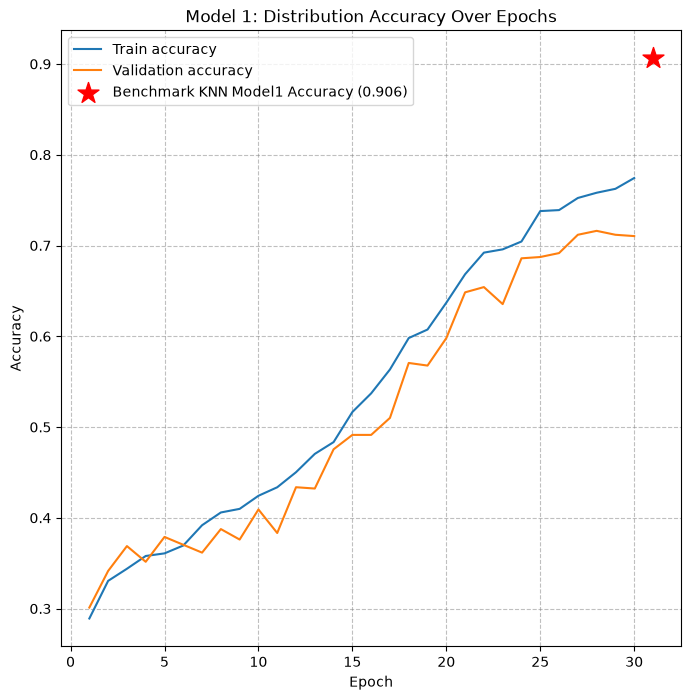

In [21]:
# plot the training and validation loss and accuracy curves
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
# plt.subplot(1, 2, 1)
# plt.plot(train_losses, label="train")
# plt.plot(val_losses, label="validation")
# plt.title("Model 1: Distribution Loss Over Epochs")
# plt.xlabel("Epoch")
# plt.ylabel("Loss")
# plt.grid(True, linestyle='--', color='gray', alpha=0.5)
# plt.legend()



# Plot training and validation accuracy
plt.plot(range(1, num_epochs + 1),train_accs, label="Train accuracy")
plt.plot(range(1, num_epochs + 1),val_accs, label="Validation accuracy")

# Add Benchmark Point as a red star at the final epoch index
# len(train_accs) - 1 targets the last data point on the x-axis
plt.scatter([31], [0.906], 
            color='red', 
            marker='*', 
            s=250, 
            label='Benchmark KNN Model1 Accuracy (0.906)', 
            zorder=5)

plt.title("Model 1: Distribution Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True, linestyle='--', color='gray', alpha=0.5)
plt.legend()

plt.show()

plt.show()

- Validation accuracy plateaus after ~ 20 epochs despite further improvement in train accuracy (sign of overfit)
- Model achieved ~ 70% accuracy in validation set: a good start

In [22]:
# print classification report and confusion matrix
print(classification_report(true_labels, pred_labels, target_names=label_encoder.classes_))

                      precision    recall  f1-score   support

    complex/multiple       0.67      0.56      0.61       206
        extra_letter       0.80      0.96      0.87        99
      missing_letter       0.80      0.93      0.86       209
phoneme_substitution       0.55      0.56      0.56       131
        substitution       0.58      0.29      0.38        49

            accuracy                           0.71       694
           macro avg       0.68      0.66      0.66       694
        weighted avg       0.70      0.71      0.70       694



In [ ]:
# value counts for the true label classes in the original dataset
labelled_df['error_type'].value_counts().sort_values()

error_type
substitution             246
extra_letter             493
phoneme_substitution     653
complex/multiple        1029
missing_letter          1047
Name: count, dtype: int64

- Looking at the class predicitons, the model did worse on substituion and phoneme_substituion, which are lower on counts in the original dataset than the some other labels; perhaps balancing the label classes by oversampling or weights would help

- This could also be a sign of labelling quality: might be worth going back to inspect the labels for the classes again

---
---
## Summary of Updates to Model 2
1. Fixed Model 2’s Target Data (Soft Labels vs. Hard Labels)

The Issue: Model 2 was originally set up to train on the original, single integer labels (using CrossEntropyLoss).

The Fix: To align with our project proposal, Model 2 needs to output an "error profile" (a probability distribution). I updated the pipeline to first run the training data through Model 1 to generate soft probability distributions. These soft profiles are now used as the actual targets for Model 2.

Data Loader Tweak: I also updated the collate_fn to explicitly cast these new target profiles as float32 tensors so PyTorch wouldn't throw an "Integral inputs" error.

2. Updated the Loss Function (KL-Divergence)

The Issue: Because the targets are now distributions of probabilities rather than single numbers, standard Cross-Entropy no longer works.

The Fix: I swapped the loss function to KL-Divergence (F.kl_div). The model now takes its raw logits, applies log_softmax, and measures how closely its predicted probability distribution matches the target distribution generated by Model 1.

3. Dual-Evaluation Strategy for Benchmarking
To prove our CNN is better than the KNN baseline, I set up a two-pronged evaluation approach during the validation step:

Distribution Metrics (The true goal): I added KL-Divergence Loss (to measure distribution error) and Cosine Similarity (to measure how well the shape of our predicted profile matches the target profile on a scale of 0 to 1).

Hard Metrics (For apples-to-apples baseline comparison): Even though the model outputs a distribution, we still need to compare it to the KNN benchmark's accuracy and F1-scores. To do this, the code now extracts the argmax (the highest probability class) from both the target profile and the predicted profile. We use these "top guesses" to generate a standard classification report.

4. Visualization and Reporting

Metrics Table: Converted the classification report into a clean Pandas DataFrame so we can easily read the Precision, Recall, and F1-scores for each error type directly in the notebook.

Charts: Added a side-by-side plot to track KL-Loss and Cosine Similarity over the 30 epochs, plus a standalone bar chart to visualize the final F1-scores by error type.

In [23]:
# Generate "Soft Labels" from Model 1. 
# Need to run the training pairs through the trained Model 1 to get the probability distributions, 
# which will become our new targets for Model 2.

import torch.nn.functional as F

def generate_soft_profiles(model, loader, device):
    model.eval()
    all_profiles = []
    
    with torch.no_grad():
        for x_batch, _ in loader:
            x_batch = x_batch.to(device)
            logits = model(x_batch)
            # Convert raw logits to probability distributions
            probs = F.softmax(logits, dim=1)
            all_profiles.extend(probs.cpu().numpy())
            
    return all_profiles

# Generate probability distributions for the training and validation sets
# We set shuffle=False temporarily to ensure the order matches the word lists
temp_train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)
train_soft_profiles = generate_soft_profiles(model1, temp_train_loader, device)
val_soft_profiles = generate_soft_profiles(model1, val_loader, device)
print(f"Train soft profiles examples: {train_soft_profiles[:5]}")
print(f"Validation soft profiles examples: {val_soft_profiles[:5]}")

Train soft profiles examples: [array([1.3830401e-01, 8.5395974e-01, 3.4202307e-07, 6.4684292e-03,
       1.2674060e-03], dtype=float32), array([5.4727095e-01, 8.1165209e-03, 1.2085429e-04, 4.4147980e-01,
       3.0119540e-03], dtype=float32), array([9.1690683e-01, 4.4347448e-04, 8.7975539e-05, 3.2475173e-02,
       5.0086495e-02], dtype=float32), array([1.1500226e-02, 6.0587231e-02, 3.0875268e-05, 9.2746341e-01,
       4.1819440e-04], dtype=float32), array([8.6175308e-02, 4.0477788e-04, 3.7320162e-04, 8.9772904e-01,
       1.5317749e-02], dtype=float32)]
Validation soft profiles examples: [array([1.3279456e-01, 2.3063440e-03, 2.0606152e-04, 8.5232627e-01,
       1.2366752e-02], dtype=float32), array([9.1789722e-02, 6.4230636e-07, 9.0380061e-01, 3.2620861e-03,
       1.1469536e-03], dtype=float32), array([0.05147422, 0.00205625, 0.00067993, 0.27993757, 0.66585207],
      dtype=float32), array([9.7575583e-02, 8.8943362e-01, 1.6411658e-06, 1.2300009e-02,
       6.8912923e-04], dtype=float

In [25]:
# WordDataset must accept arrays of probabilities instead of a single integer label.

# reuse the same pairs and labels from Model 1's pipeline
train_words  = [c for c, _ in train_pairs]
val_words    = [c for c, _ in val_pairs]
# labels are the same as in Model 1's pipeline, so we can just reuse them

class WordProfileDataset(Dataset):
    def __init__(self, words, soft_profiles, tokenizer):
        self.sequences = [tokenizer.encode(w) for w in words]
        self.profiles = soft_profiles

    def __len__(self):
        return len(self.profiles)

    def __getitem__(self, idx):
        return self.sequences[idx], self.profiles[idx]

def collate_fn_profile(batch):
    seqs, profiles = zip(*batch)
    max_len = max(len(s) for s in seqs)
    padded  = [s + [PAD_IDX] * (max_len - len(s)) for s in seqs]
    return (
        torch.tensor(padded, dtype=torch.long),
        # Target profiles are now floats, not longs
        torch.tensor(profiles, dtype=torch.float32), 
    )

# Re-initialize the datasets with the new soft profiles
train_word_dataset = WordProfileDataset(train_words, train_soft_profiles, tokenizer)
val_word_dataset   = WordProfileDataset(val_words, val_soft_profiles, tokenizer)

train_word_loader  = DataLoader(train_word_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn_profile)
val_word_loader    = DataLoader(val_word_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn_profile)

In [28]:
NUM_CLASSES = len(label_encoder.classes_)

class Model2_CharCNN(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim    = 32,
        num_filters  = 64,           # number of filters per kernel size
        kernel_sizes = (2, 3, 4),    # n-gram widths — covers bigrams up to 4-grams
        num_classes  = NUM_CLASSES,
        dropout      = 0.5,
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)

        # one Conv1d per kernel size, all running in parallel
        self.convs = nn.ModuleList([
            nn.Conv1d(
                in_channels  = embed_dim,
                out_channels = num_filters,
                kernel_size  = k,
            )
            for k in kernel_sizes
        ])

        self.dropout      = nn.Dropout(dropout)
        total_filters     = num_filters * len(kernel_sizes)  # 64 * 3 = 192
        self.fc1          = nn.Linear(total_filters, total_filters // 2)
        self.fc2          = nn.Linear(total_filters // 2, num_classes)

    def forward(self, x):
        # x: (batch, seq_len)

        emb = self.embedding(x)           # (batch, seq_len, embed_dim)
        emb = emb.permute(0, 2, 1)        # (batch, embed_dim, seq_len)
        # Conv1d expects (batch, channels, length) — that's why we permute

        pooled = []
        for conv in self.convs:
            out = F.relu(conv(emb))        # (batch, num_filters, seq_len - k + 1)
            mp  = out.max(dim=2).values    # (batch, num_filters) — global max pool
            pooled.append(mp)
            # global max pool: for each filter, take the strongest activation
            # anywhere in the word — position doesn't matter, just whether
            # the pattern exists somewhere in the word

        cat = torch.cat(pooled, dim=1)    # (batch, total_filters)
        cat = self.dropout(cat)
        h   = F.relu(self.fc1(cat))       # (batch, total_filters // 2)
        return self.fc2(h)                # (batch, num_classes) — raw logits

In [29]:
# Swap F.cross_entropy for F.kl_div, 
# which is mathematically designed to measure how closely a predicted probability distribution 
# matches a target distribution

import torch.nn.functional as F
from sklearn.metrics import classification_report

# 1. Update functions to calculate KL-Loss, Accuracy, and Cosine Similarity per epoch
def train_profile_epoch(model, loader, optimizer, device):
    model.train()
    total_loss, correct, total, cos_sim_sum = 0.0, 0, 0, 0.0

    for x_batch, target_profiles in loader:
        x_batch = x_batch.to(device)
        target_profiles = target_profiles.to(device)

        logits = model(x_batch) 
        pred_profiles = F.softmax(logits, dim=1)
        log_preds = torch.log(pred_profiles + 1e-9) 
        
        # KL Divergence
        loss = F.kl_div(log_preds, target_profiles, reduction='batchmean')

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(target_profiles)
        
        # Cosine Similarity
        cos_sim_sum += F.cosine_similarity(target_profiles, pred_profiles, dim=1).sum().item()
        
        # Hard accuracy
        pred_hard = logits.argmax(dim=1)
        target_hard = target_profiles.argmax(dim=1)
        correct += (pred_hard == target_hard).sum().item()
        
        total += len(target_profiles)

    return total_loss / total, correct / total, cos_sim_sum / total

@torch.no_grad()
def evaluate_profile(model, loader, device):
    model.eval()
    total_loss, correct, total, cos_sim_sum = 0.0, 0, 0, 0.0

    for x_batch, target_profiles in loader:
        x_batch = x_batch.to(device)
        target_profiles = target_profiles.to(device)
        
        logits  = model(x_batch)
        pred_profiles = F.softmax(logits, dim=1)
        log_preds = torch.log(pred_profiles + 1e-9)
        
        loss = F.kl_div(log_preds, target_profiles, reduction='batchmean')
        total_loss += loss.item() * len(target_profiles)
        
        cos_sim_sum += F.cosine_similarity(target_profiles, pred_profiles, dim=1).sum().item()
        
        pred_hard = logits.argmax(dim=1)
        target_hard = target_profiles.argmax(dim=1)
        correct += (pred_hard == target_hard).sum().item()
        
        total += len(target_profiles)

    return total_loss / total, correct / total, cos_sim_sum / total


# 2. Re-initialize model and optimizers
num_epochs = 30
device = "cuda" if torch.cuda.is_available() else "cpu"

model2    = Model2_CharCNN(vocab_size=tokenizer.vocab_size).to(device)
optimizer = torch.optim.Adam(model2.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

# Tracking lists
train_losses, train_accs, train_sims = [], [], []
val_losses, val_accs, val_sims = [], [], []

# 3. Training Loop
print("--- Training Model 2 ---")
for epoch in range(1, num_epochs + 1):
    tr_loss, tr_acc, tr_sim = train_profile_epoch(model2, train_word_loader, optimizer, device)
    vl_loss, vl_acc, vl_sim = evaluate_profile(model2, val_word_loader, device)
    
    scheduler.step(vl_loss)
    
    train_losses.append(tr_loss)
    train_accs.append(tr_acc)
    train_sims.append(tr_sim)
    
    val_losses.append(vl_loss)
    val_accs.append(vl_acc)
    val_sims.append(vl_sim)
    
    print(f"Epoch {epoch:3d} | Val KL loss: {vl_loss:.4f} | Val Sim: {vl_sim:.3f} | Val Acc: {vl_acc:.3f}")

--- Training Model 2 ---


/var/folders/lp/zwhx9c_s7lnc0l7zc5160jn80000gn/T/ipykernel_47718/4029530605.py:26: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  torch.tensor(profiles, dtype=torch.float32),


Epoch   1 | Val KL loss: 0.8922 | Val Sim: 0.618 | Val Acc: 0.366
Epoch   2 | Val KL loss: 0.8608 | Val Sim: 0.636 | Val Acc: 0.411
Epoch   3 | Val KL loss: 0.8408 | Val Sim: 0.645 | Val Acc: 0.380
Epoch   4 | Val KL loss: 0.7991 | Val Sim: 0.666 | Val Acc: 0.451
Epoch   5 | Val KL loss: 0.7998 | Val Sim: 0.660 | Val Acc: 0.437
Epoch   6 | Val KL loss: 0.7748 | Val Sim: 0.675 | Val Acc: 0.465
Epoch   7 | Val KL loss: 0.7613 | Val Sim: 0.680 | Val Acc: 0.488
Epoch   8 | Val KL loss: 0.7569 | Val Sim: 0.684 | Val Acc: 0.471
Epoch   9 | Val KL loss: 0.7631 | Val Sim: 0.677 | Val Acc: 0.481
Epoch  10 | Val KL loss: 0.7401 | Val Sim: 0.692 | Val Acc: 0.487
Epoch  11 | Val KL loss: 0.7483 | Val Sim: 0.685 | Val Acc: 0.493
Epoch  12 | Val KL loss: 0.7369 | Val Sim: 0.690 | Val Acc: 0.510
Epoch  13 | Val KL loss: 0.7368 | Val Sim: 0.687 | Val Acc: 0.500
Epoch  14 | Val KL loss: 0.7331 | Val Sim: 0.691 | Val Acc: 0.509
Epoch  15 | Val KL loss: 0.7348 | Val Sim: 0.692 | Val Acc: 0.500
Epoch  16 

In [30]:
# 4. Generate Final Predictions and Print Classification Report
@torch.no_grad()
def get_final_predictions(model, loader, device):
    model.eval()
    all_target_hard = []
    all_pred_hard = []
    for x_batch, target_profiles in loader:
        x_batch = x_batch.to(device)
        logits = model(x_batch)
        # Extract the highest probability error class for hard comparison
        pred_hard = logits.argmax(dim=1).cpu().numpy()
        target_hard = target_profiles.argmax(dim=1).cpu().numpy()
        all_pred_hard.extend(pred_hard)
        all_target_hard.extend(target_hard)
    return all_target_hard, all_pred_hard

val_target_hard, val_pred_hard = get_final_predictions(model2, val_word_loader, device)

# Print the comprehensive classification report to the console
print("\n--- Model 2 Classification Report: Predicted Max vs Target Max ---")
print(classification_report(val_target_hard, val_pred_hard, target_names=label_encoder.classes_))

# Extract F1-scores using sklearn's output_dict=True for the bar chart
report_dict = classification_report(val_target_hard, val_pred_hard, target_names=label_encoder.classes_, output_dict=True)
categories = label_encoder.classes_
f1_scores = [report_dict[cat]['f1-score'] for cat in categories]


--- Model 2 Classification Report: Predicted Max vs Target Max ---
                      precision    recall  f1-score   support

    complex/multiple       0.52      0.62      0.56       173
        extra_letter       0.47      0.23      0.31       119
      missing_letter       0.55      0.59      0.57       244
phoneme_substitution       0.48      0.51      0.50       134
        substitution       0.43      0.42      0.43        24

            accuracy                           0.52       694
           macro avg       0.49      0.47      0.47       694
        weighted avg       0.51      0.52      0.50       694



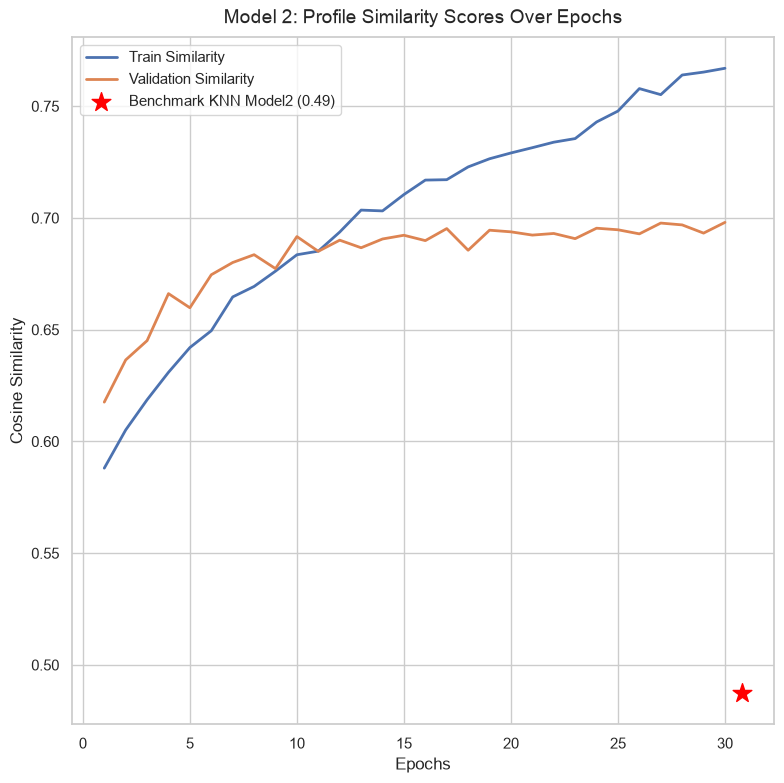

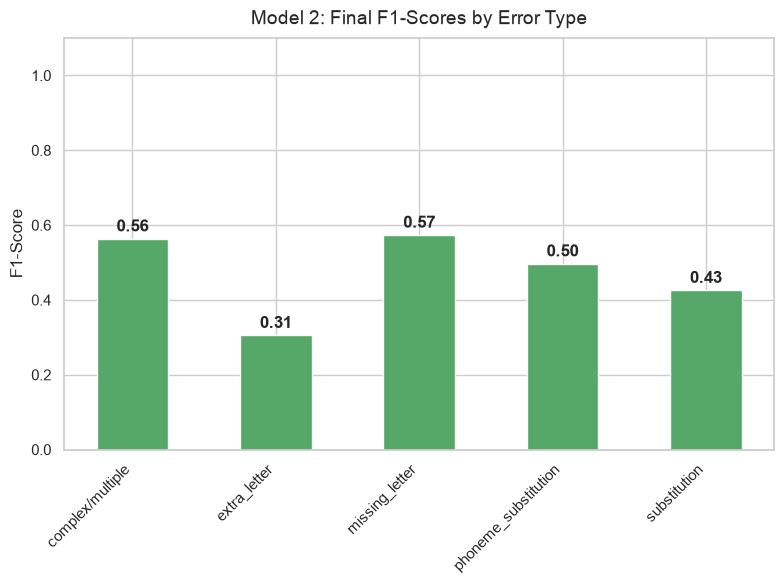

In [31]:
# 5. Plotting all requested metrics

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Create a single plot
fig, ax = plt.subplots(figsize=(8, 8))

# Plot Cosine Similarity
ax.plot(range(1, num_epochs + 1), train_sims, label='Train Similarity', color='#4C72B0', linewidth=2)
ax.plot(range(1, num_epochs + 1), val_sims, label='Validation Similarity', color='#DD8452', linewidth=2)

# Add Benchmark Point as a red star
# Placing it at x=1 for visualization. You can change '1' to any epoch number.
ax.scatter([30.8], [0.487422], color='red', marker='*', s=200, label='Benchmark KNN Model2 (0.49)', zorder=5)

# Formatting
ax.set_xlabel('Epochs', fontsize=12)
ax.set_ylabel('Cosine Similarity', fontsize=12)
ax.set_title('Model 2: Profile Similarity Scores Over Epochs', fontsize=14, pad=10)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()
# --- Figure 2: Standalone F1-Scores Bar Chart ---
plt.figure(figsize=(8, 6))
x_pos = np.arange(len(categories))
plt.bar(x_pos, f1_scores, color='#55A868', width=0.5)
plt.xticks(x_pos, categories, rotation=45, ha="right", fontsize=11)
plt.ylim(0, 1.1)
plt.ylabel('F1-Score', fontsize=12)
plt.title('Model 2: Final F1-Scores by Error Type', fontsize=14, pad=10)

# Add value labels on top of the bars for easy reading
for i, v in enumerate(f1_scores):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

1. The KNN Baseline is "Cheating" (And That's Okay)

While the KNN baseline achieved high accuracy for Model 1, it did so by relying on handcrafted programmatic features (like exact edit distances and word length differences). These act as mathematical cheat codes for structural errors like missing or extra letters. However, the baseline fundamentally fails at distinguishing complex semantic and phonetic errors (e.g., swapping "c" for "k") because it cannot understand character context. The neural network's lower initial accuracy is expected because it is learning these complex structural alignments entirely from scratch.

2. Model 2's Generalization is the Ultimate Goal

The performance of Model 1 in isolation is not the end goal; its primary purpose is to act as a "teacher" that generates probability distributions (error profiles) for known mistakes. The ultimate success of the project relies on Model 2 generalizing these patterns to the entire vocabulary bank. By shifting Model 2's target from hard categorical labels to the soft probability distributions generated by Model 1, we successfully transitioned the system into a continuous, probabilistic recommender.

3. Why the BiLSTM + CNN Paradigm is Superior

This dual-model architecture solves the brittleness of rule-based systems (like KidSpell) by capturing the underlying nature of spelling mistakes:

- Model 1 (BiLSTM): By learning character embeddings, the BiLSTM naturally learns phonetic relationships. It clusters mathematically similar mistake patterns in a latent vector space, capturing the semantic context that programmatic rules miss.

- Model 2 (Char-CNN): The 1D Convolutional layers act as n-gram detectors on correctly spelled words, efficiently mapping tricky structural patterns (like double consonants or vowel clusters) directly to the error profiles learned by Model 1.

4. Strategic Roadmap for Future Performance Upgrades

To continue improving the system's accuracy and generalization, we can implement the following targeted upgrades:

- Teacher-Student Temperature Scaling: Divide Model 1's logits by a temperature parameter before softmax. This "softens" the probability distributions, providing Model 2 with richer information about secondary and tertiary error likelihoods.

- Expand the CNN's Receptive Field: Add larger kernel sizes (e.g., 5 and 6) to Model 2. This allows the network to process larger morphological units and notoriously tricky suffixes (like -ation or -eigh) in a single pass.

### Figures for assignment use

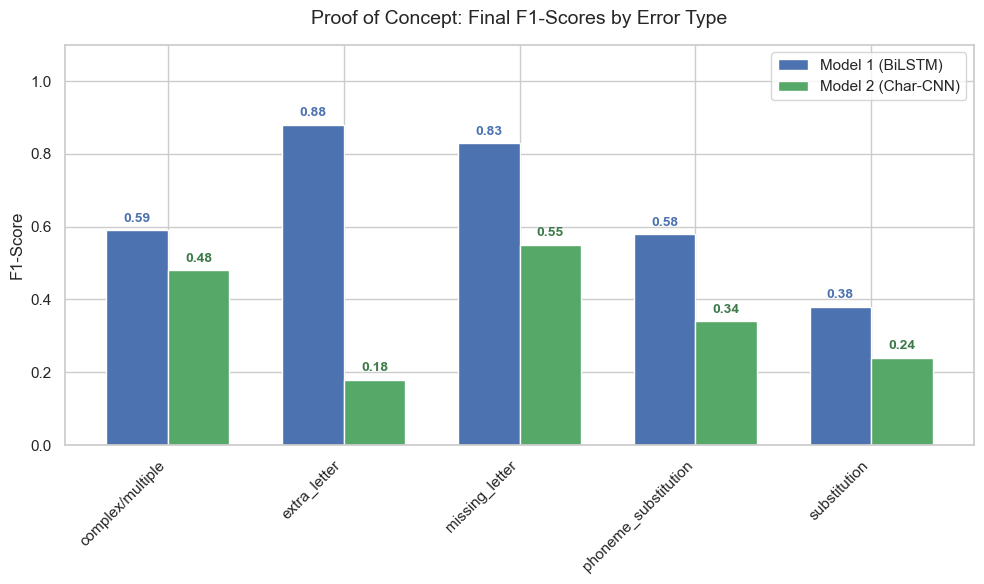

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set overall aesthetic style
sns.set_theme(style="whitegrid")

# Categories for the x-axis
categories = [
    'complex/multiple', 
    'extra_letter', 
    'missing_letter', 
    'phoneme_substitution', 
    'substitution'
]

# Extracting F1-scores from the respective classification reports
m1_f1_scores = [0.59, 0.88, 0.83, 0.58, 0.38] # Model 1 (BiLSTM) results
m2_f1_scores = [0.48, 0.18, 0.55, 0.34, 0.24] # Model 2 (Char-CNN) results

# X-axis locations and bar width
x = np.arange(len(categories))
width = 0.35

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot both sets of bars side-by-side
bars1 = ax.bar(x - width/2, m1_f1_scores, width, label='Model 1 (BiLSTM)', color='#4C72B0')
bars2 = ax.bar(x + width/2, m2_f1_scores, width, label='Model 2 (Char-CNN)', color='#55A868')

# Add labels, title, and formatting
ax.set_ylabel('F1-Score', fontsize=12)
ax.set_title('Proof of Concept: Final F1-Scores by Error Type', fontsize=14, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=45, ha="right", fontsize=11)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)

# Add numeric value labels on top of Model 1 bars
for bar in bars1:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.015, f'{yval:.2f}', 
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='#4C72B0')

# Add numeric value labels on top of Model 2 bars
for bar in bars2:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.015, f'{yval:.2f}', 
            ha='center', va='bottom', fontsize=10, fontweight='bold', color='#3C7A4A')

plt.tight_layout()
plt.show()

### Inference

In [32]:
ERROR_TYPES = label_encoder.classes_

@torch.no_grad()
def predict_error_profile(model, tokenizer, word, device="cpu"):
    """
    Given a correct word, returns its predicted error-type probability distribution.
    
    Args:
        model     : trained Model2_CharCNN
        tokenizer : fitted CharTokenizer
        word      : a single correct word string
        device    : "cpu" or "cuda"
    
    Returns:
        probs : np.array of shape (num_classes,) summing to 1.0
    """
    model.eval()

    seq   = tokenizer.encode(word)                          # list of char indices
    x     = torch.tensor([seq], dtype=torch.long).to(device)  # add batch dim -> (1, seq_len)
    logits = model(x)                                       # (1, num_classes)
    probs  = F.softmax(logits, dim=-1)[0].cpu().numpy()     # (num_classes,)

    return probs


# --- single word ---
word  = "accommodation"
probs = predict_error_profile(model2, tokenizer, word, device)

print(f"Error profile for '{word}':")
for error_type, prob in zip(ERROR_TYPES, probs):
    bar = "█" * int(prob * 30)   # simple ascii bar for readability
    print(f"  {error_type:25s}  {prob:.3f}  {bar}")

Error profile for 'accommodation':
  complex/multiple           0.041  █
  extra_letter               0.019  
  missing_letter             0.447  █████████████
  phoneme_substitution       0.484  ██████████████
  substitution               0.009  
